# The aim of this file is to understand the raw data we collected.

The scaper was unable to collect the floor vs total floors correctly so we had to impute 1221 floors_total values by assuming the apartment had double the amount of floors.

One other way to try would be impute by the average ratio of floor number to total floors.

## First we install necessary imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os

## load data


In [2]:
listing_data = pd.read_csv('raw_data/listings.csv')
images_data = pd.read_csv('raw_data/images.csv')

# EDA
- remove the lisitings with less than 5 images and remove images from images.csv


In [3]:
listing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5194 entries, 0 to 5193
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        5194 non-null   int64  
 1   url              5194 non-null   str    
 2   price_man_yen    5112 non-null   float64
 3   layout           5096 non-null   str    
 4   area_sqm         5138 non-null   float64
 5   year_built       5194 non-null   int64  
 6   floor_number     5138 non-null   float64
 7   floors_total     5138 non-null   float64
 8   address          5194 non-null   str    
 9   nearest_station  5183 non-null   str    
 10  walk_minutes     5183 non-null   float64
 11  image_count      5194 non-null   int64  
dtypes: float64(5), int64(3), str(4)
memory usage: 487.1 KB


In [4]:
images_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99750 entries, 0 to 99749
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   source_id    99750 non-null  int64
 1   listing_url  99750 non-null  str  
 2   image_url    99750 non-null  str  
 3   image_name   99750 non-null  str  
dtypes: int64(1), str(3)
memory usage: 3.0 MB


In [5]:
listing_data.describe()

,source_id,price_man_yen,area_sqm,year_built,floor_number,floors_total,walk_minutes,image_count
count,5.194000e+03,5112.000000,5138.000000,5194.000000,5138.000000,5138.000000,5183.000000,5194.000000
mean,4.713587e+07,11691.727113,65.977024,1997.946284,7.898015,7.402686,7.590199,19.204852
std,2.919093e+07,12519.704491,21.960892,15.691200,8.507329,6.791477,4.677883,16.315492
min,2.000007e+07,10.000000,16.510000,1964.000000,1.000000,1.000000,1.000000,1.000000
25%,2.020922e+07,4980.000000,53.472500,1983.000000,3.000000,2.000000,4.000000,12.000000
50%,2.035380e+07,7980.000000,63.900000,2000.000000,5.000000,7.000000,7.000000,22.000000
75%,7.889139e+07,13980.000000,75.310000,2010.000000,9.000000,11.000000,10.000000,27.000000
max,7.923565e+07,216800.000000,383.640000,2026.000000,59.000000,58.000000,46.000000,805.000000


In [6]:
listing_data.shape

(5194, 12)

In [7]:
images_data.shape

(99750, 4)

In [8]:
listing_data.columns

Index(['source_id', 'url', 'price_man_yen', 'layout', 'area_sqm', 'year_built',
       'floor_number', 'floors_total', 'address', 'nearest_station',
       'walk_minutes', 'image_count'],
      dtype='str')

In [9]:
images_data.columns

Index(['source_id', 'listing_url', 'image_url', 'image_name'], dtype='str')

In [10]:
listing_data.source_id.nunique()

5194

In [11]:
images_data.source_id.nunique()

5194

In [12]:
listing_data.isna().any()

source_id          False
url                False
price_man_yen       True
layout              True
area_sqm            True
year_built         False
floor_number        True
floors_total        True
address            False
nearest_station     True
walk_minutes        True
image_count        False
dtype: bool

In [13]:
listing_data = listing_data.dropna()

## Understanding outliers within the price man yen target variable

In [45]:
listing_data['price_man_yen'].describe()

count      3989.000000
mean      12536.155929
std       12987.639999
min        1380.000000
25%        5498.000000
50%        8780.000000
75%       14980.000000
max      216800.000000
Name: price_man_yen, dtype: float64

In [49]:
listing_data['price_man_yen'].sort_values().tail(20)

3878     84800.0
3869     85000.0
3865     87800.0
3863     88000.0
3866     88000.0
3868     88000.0
3871     99980.0
3881    105000.0
3873    107000.0
3875    107000.0
3882    108000.0
3867    112000.0
3883    118000.0
3880    119800.0
3872    126000.0
3885    137000.0
3887    148800.0
3877    173000.0
3874    177000.0
3870    216800.0
Name: price_man_yen, dtype: float64

In [48]:
listing_data['price_man_yen'].sort_values().head(20)

9       1380.0
16      1380.0
1       1480.0
3       1580.0
27      1580.0
14      1580.0
19      1600.0
3888    1680.0
5       1700.0
20      1780.0
21      1780.0
6       1800.0
23      1880.0
7       1880.0
18      1880.0
26      1980.0
3923    2000.0
12      2080.0
25      2180.0
0       2180.0
Name: price_man_yen, dtype: float64

In [57]:
from scipy.stats import zscore

listing_data['price_zscore'] = zscore(listing_data['price_man_yen'])
outliers = listing_data[listing_data['price_zscore'].abs() > 3]
listing_data = listing_data[listing_data['price_zscore'].abs() <= 3]
listing_data = listing_data.drop('price_zscore', axis=1)

In [53]:
outliers['price_man_yen'].sort_values()

3813     51800.0
3834     51960.0
3829     52000.0
3810     52000.0
3823     52800.0
          ...   
3885    137000.0
3887    148800.0
3877    173000.0
3874    177000.0
3870    216800.0
Name: price_man_yen, Length: 67, dtype: float64

In [59]:
listing_data['price_man_yen'].sort_values()

9        1380.0
16       1380.0
1        1480.0
3        1580.0
27       1580.0
         ...   
3644    30990.0
3652    31000.0
3642    31100.0
3640    31100.0
3641    31580.0
Name: price_man_yen, Length: 3756, dtype: float64

In [15]:
images_data.isna().any()

source_id      False
listing_url    False
image_url      False
image_name     False
dtype: bool

In [16]:
#keep only the listings that have 5 or more images
listing_data = listing_data[listing_data['image_count'] >= 5]
listing_data

,source_id,url,price_man_yen,layout,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count
2,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2180.0,2LDK,60.33,1988,5.0,14.0,東京都足立区辰沼２ [ ■ 周辺環境 ],バス11分六木一丁目駅,5.0,24
3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,1K,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10
4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,2LDK,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24
5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,1DK,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31
6,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,2LDK,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,7.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
5169,20383865,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,3990.0,2LDK,62.26,1992,2.0,13.0,東京都足立区千住河原町 [ ■ 周辺環境 ],千住大橋駅,3.0,22
5170,20387717,https://suumo.jp/ms/chuko/tokyo/sc_edogawa/nc_...,3990.0,2LDK,60.75,1977,3.0,10.0,東京都江戸川区平井３-5-1 [ ■ 周辺環境 ],平井駅,8.0,13
5171,20383403,https://suumo.jp/ms/chuko/tokyo/sc_itabashi/nc...,3999.0,1LDK,43.31,1986,10.0,14.0,東京都板橋区熊野町 [ ■ 周辺環境 ],大山駅,6.0,27
5172,20381394,https://suumo.jp/ms/chuko/tokyo/sc_setagaya/nc...,4000.0,2LDK,42.51,1970,2.0,13.0,東京都世田谷区上馬４ [ ■ 周辺環境 ],駒沢大学駅,2.0,15


In [17]:
#remove the images of listings not being used
images_data = images_data[images_data['source_id'].isin(listing_data['source_id'])]
images_data


,source_id,listing_url,image_url,image_name
2,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20071087_4fa3bd581c.jpg
3,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20071087_f70dacff50.jpg
4,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20071087_f2e5fe2057.jpg
5,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20071087_7c83041940.jpg
6,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20071087_22d14e392f.jpg
...,...,...,...,...
99387,20112263,https://suumo.jp/ms/chuko/tokyo/sc_itabashi/nc...,https://suumo.jp/front/gazo/bukken/030/N010000...,20112263_b389b02d7a.jpg
99388,20112263,https://suumo.jp/ms/chuko/tokyo/sc_itabashi/nc...,https://suumo.jp/front/gazo/bukken/030/N010000...,20112263_74d74b7336.jpg
99389,20112263,https://suumo.jp/ms/chuko/tokyo/sc_itabashi/nc...,https://suumo.jp/front/gazo/bukken/030/N010000...,20112263_11f363c182.jpg
99390,20112263,https://suumo.jp/ms/chuko/tokyo/sc_itabashi/nc...,https://suumo.jp/edit/assets/suumo/img/pagetop...,20112263_dbe2b604b6.png


## Inspecting the distributions of columns in listings data.

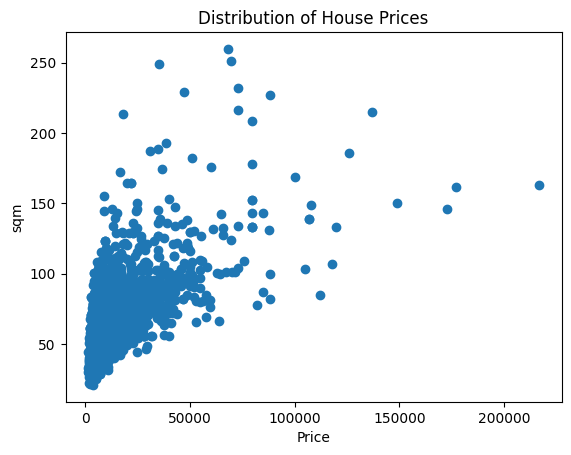

In [18]:
price = listing_data['price_man_yen']
sqm = listing_data['area_sqm']
plt.scatter(price,sqm)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("sqm")
plt.show()

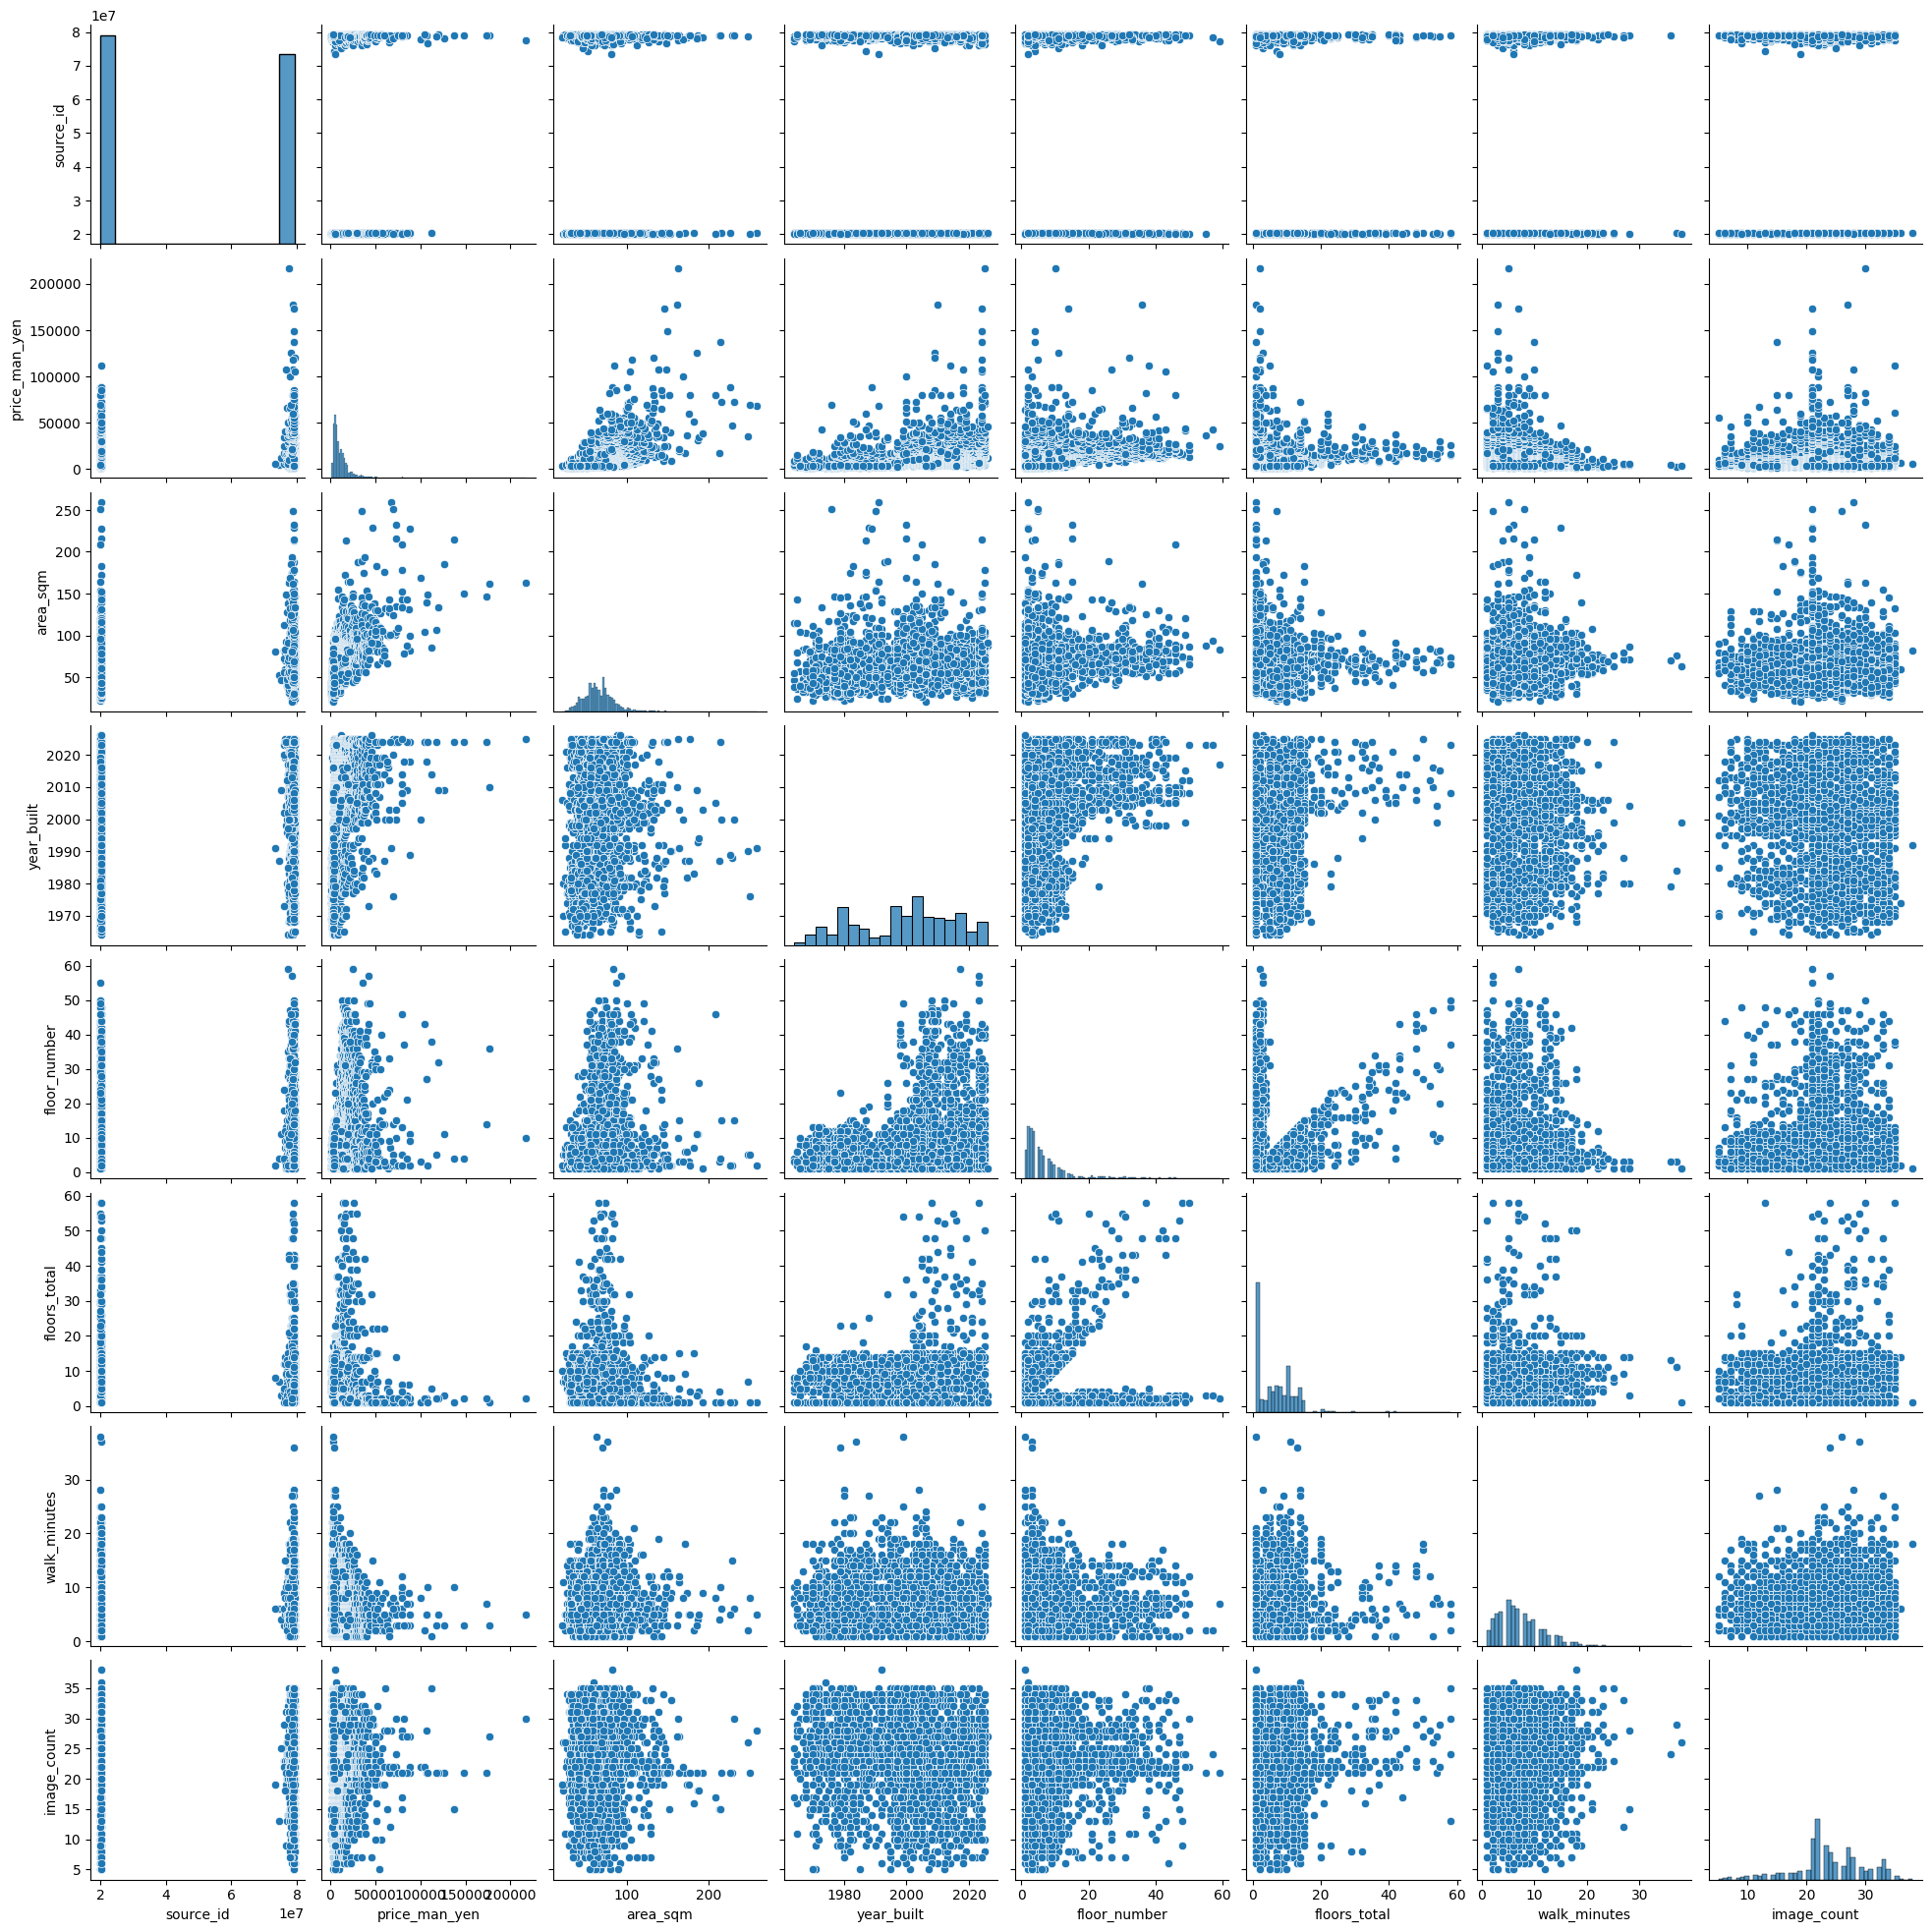

In [19]:
plot = sns.pairplot(listing_data)

### Why are some apartments on higher floor than total floors on building?

In [20]:
# find the number of listings that have floor number higher than floors_total
floating_apartments = listing_data[['source_id','floor_number', 'floors_total']]
floating_apartments = floating_apartments[floating_apartments['floor_number'] > floating_apartments['floors_total']]
new_total_floors = floating_apartments['floor_number'] * 2
floating_apartments['floors_total'] = new_total_floors
new_total_floors

189      8.0
194      8.0
207      8.0
254     10.0
255     14.0
        ... 
5126     8.0
5156     6.0
5160     6.0
5163    12.0
5166     4.0
Name: floor_number, Length: 1230, dtype: float64

In [21]:
#Function to replace floating apartments floors_total with double the floor_number value
def fix_floating(row):
    if row['floor_number'] > row['floors_total']:
        row['floors_total'] = row['floor_number'] * 2

    return row

In [22]:
listing_data.apply(fix_floating, axis=1)

,source_id,url,price_man_yen,layout,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count
2,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2180.0,2LDK,60.33,1988,5.0,14.0,東京都足立区辰沼２ [ ■ 周辺環境 ],バス11分六木一丁目駅,5.0,24
3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,1K,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10
4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,2LDK,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24
5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,1DK,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31
6,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,2LDK,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,7.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
5169,20383865,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,3990.0,2LDK,62.26,1992,2.0,13.0,東京都足立区千住河原町 [ ■ 周辺環境 ],千住大橋駅,3.0,22
5170,20387717,https://suumo.jp/ms/chuko/tokyo/sc_edogawa/nc_...,3990.0,2LDK,60.75,1977,3.0,10.0,東京都江戸川区平井３-5-1 [ ■ 周辺環境 ],平井駅,8.0,13
5171,20383403,https://suumo.jp/ms/chuko/tokyo/sc_itabashi/nc...,3999.0,1LDK,43.31,1986,10.0,14.0,東京都板橋区熊野町 [ ■ 周辺環境 ],大山駅,6.0,27
5172,20381394,https://suumo.jp/ms/chuko/tokyo/sc_setagaya/nc...,4000.0,2LDK,42.51,1970,2.0,13.0,東京都世田谷区上馬４ [ ■ 周辺環境 ],駒沢大学駅,2.0,15


# Inspect Categorical Features

In [23]:
listing_data['layout'].value_counts()

layout
2LDK     1524
3LDK     1386
1LDK      732
4LDK      115
2DK        78
1DK        66
1K         25
3DK        25
1R         12
2K          4
5LDK        4
2SLDK       3
３LDK        3
1SLDK       3
4DK         2
２LDK        2
２DK         1
１R          1
3K          1
6LDK        1
4SLDK       1
Name: count, dtype: int64

<Axes: xlabel='layout', ylabel='area_sqm'>

/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 65297 (\N{FULLWIDTH DIGIT ONE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 65299 (\N{FULLWIDTH DIGIT THREE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/pyl

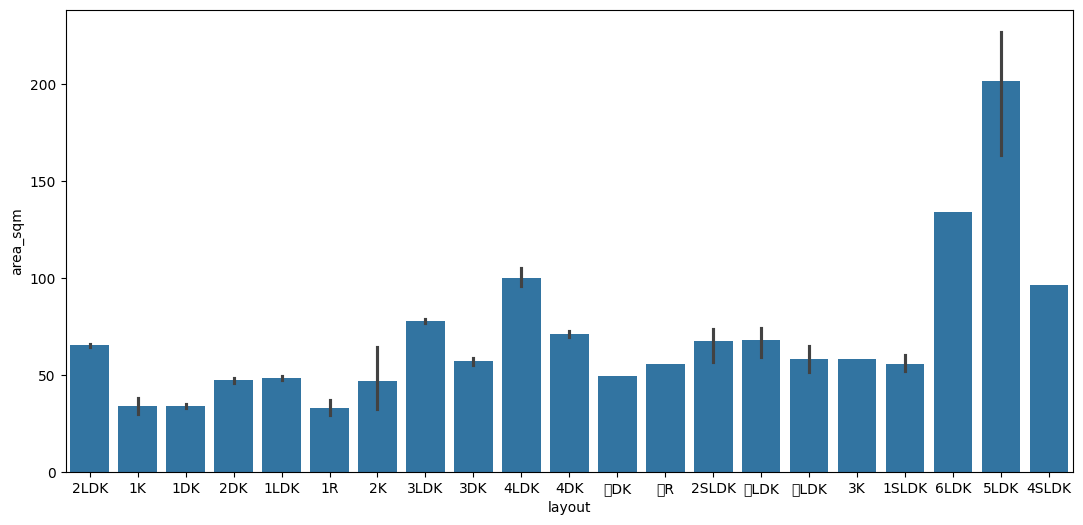

In [24]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=listing_data, x=listing_data['layout'], y=listing_data['area_sqm'], ax=ax)

## try to reformat the layout to be easier to use during preprocessing


In [25]:
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

_layout_re = re.compile(r"^\s*(\d+)\s*(S?)\s*(LDK|DK|K|R)\s*$", re.IGNORECASE)

_fw_digits = str.maketrans("０１２３４５６７８９", "0123456789")

def parse_layout(X):
    """
    Input: X as 2D array (n_samples, 1) containing layout strings
    Output: DataFrame with columns:
      - rooms_num (int)
      - base_layout (str: LDK/DK/K/R)
      - has_S (int 0/1)
    """
    s = pd.Series(np.asarray(X).ravel()).fillna("").astype(str)
    s = s.str.translate(_fw_digits).str.strip().str.upper()

    rooms = []
    base = []
    has_s = []

    for val in s:
        m = _layout_re.match(val)
        if not m:
            rooms.append(np.nan)
            base.append("UNKNOWN")
            has_s.append(0)
        else:
            rooms.append(int(m.group(1)))
            has_s.append(1 if m.group(2) == "S" else 0)
            base.append(m.group(3))  # LDK/DK/K/R

    return pd.DataFrame({
        "rooms_num": rooms,
        "base_layout": base,
        "has_S": has_s
    })

layout_parser = FunctionTransformer(parse_layout, feature_names_out="one-to-one")

In [26]:
layout = listing_data['layout']
layout.value_counts()

layout
2LDK     1524
3LDK     1386
1LDK      732
4LDK      115
2DK        78
1DK        66
1K         25
3DK        25
1R         12
2K          4
5LDK        4
2SLDK       3
３LDK        3
1SLDK       3
4DK         2
２LDK        2
２DK         1
１R          1
3K          1
6LDK        1
4SLDK       1
Name: count, dtype: int64

In [27]:
layout_parsed = parse_layout(layout)
layout_parsed['has_S'].value_counts()
layout_parsed = layout_parsed.drop(['has_S'], axis= 1)
listing_data = listing_data.reset_index().join(layout_parsed).drop(['layout'], axis=1)


In [28]:
listing_data

,index,source_id,url,price_man_yen,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count,rooms_num,base_layout
0,2,20071087,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2180.0,60.33,1988,5.0,14.0,東京都足立区辰沼２ [ ■ 周辺環境 ],バス11分六木一丁目駅,5.0,24,2,LDK
1,3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10,1,K
2,4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24,2,LDK
3,5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31,1,DK
4,6,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,7.0,27,2,LDK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3984,5169,20383865,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,3990.0,62.26,1992,2.0,13.0,東京都足立区千住河原町 [ ■ 周辺環境 ],千住大橋駅,3.0,22,2,LDK
3985,5170,20387717,https://suumo.jp/ms/chuko/tokyo/sc_edogawa/nc_...,3990.0,60.75,1977,3.0,10.0,東京都江戸川区平井３-5-1 [ ■ 周辺環境 ],平井駅,8.0,13,2,LDK
3986,5171,20383403,https://suumo.jp/ms/chuko/tokyo/sc_itabashi/nc...,3999.0,43.31,1986,10.0,14.0,東京都板橋区熊野町 [ ■ 周辺環境 ],大山駅,6.0,27,1,LDK
3987,5172,20381394,https://suumo.jp/ms/chuko/tokyo/sc_setagaya/nc...,4000.0,42.51,1970,2.0,13.0,東京都世田谷区上馬４ [ ■ 周辺環境 ],駒沢大学駅,2.0,15,2,LDK


In [29]:
listing_data['nearest_station'].value_counts().tail(30)

nearest_station
仲御徒町駅     1
熊野前駅      1
練馬春日町駅    1
有楽町駅      1
鐘ヶ淵駅      1
豪徳寺駅      1
南新宿駅      1
立会川駅      1
雪が谷大塚駅    1
東長崎駅      1
保谷駅       1
荏原中延駅     1
志茂駅       1
西早稲田駅     1
洗足池駅      1
鶯谷駅駅      1
東松原駅      1
北品川駅      1
戸越公園駅     1
緑が丘駅      1
下高井戸駅     1
青物横丁駅     1
久が原駅      1
晴海埠頭駅     1
国際展示場駅    1
新橋駅       1
宝町駅       1
東北沢駅      1
国立競技場駅    1
八潮駅       1
Name: count, dtype: int64

## plotting new clip features to see correlation


In [41]:
X_train_preprocessed = pd.read_csv('data_dump/X_train_preprocessed.csv')
y = pd.read_csv('data_dump/y_train_preprocessed.csv')

train_data = y.join(X_train_preprocessed)
train_data

,price_man_yen,keep_rooms__rooms_num,num_transformer__area_sqm,num_transformer__year_built,num_transformer__floor_number,num_transformer__floors_total,num_transformer__walk_minutes,station_transformer__nearest_station,ordinal_transformer__base_layout,mean_luxury_transformer__mean_luxury,mean_brightness_transformer__mean_brightness,mean_condition_transformer__mean_condition
0,7.930566,2.0,-0.220727,-0.703704,0.571429,0.111111,-0.500000,2690.250981,3.0,0.220785,0.447754,0.887777
1,9.797071,2.0,-0.324127,0.481481,3.714286,5.777778,-1.000000,17777.103538,3.0,0.452474,0.710612,0.969401
2,9.614538,3.0,0.571530,0.851852,0.571429,0.888889,-0.833333,9623.434378,3.0,0.529622,0.861654,0.972819
3,8.809863,3.0,0.487960,-0.925926,-0.142857,-0.666667,-0.666667,9721.328697,3.0,0.430664,0.655273,0.920247
4,8.289288,3.0,0.448300,-0.703704,0.285714,-0.111111,1.000000,11840.994629,3.0,0.266992,0.637305,0.867578
...,...,...,...,...,...,...,...,...,...,...,...,...
2307,8.064951,1.0,-1.648489,-0.629630,-0.142857,-0.222222,1.166667,7034.201278,2.0,0.472656,0.710156,0.941250
2308,8.809863,3.0,0.487960,-0.925926,-0.142857,-0.666667,0.500000,9721.328697,3.0,0.635347,0.923816,0.966704
2309,8.155075,2.0,-1.187677,-0.592593,-0.571429,-0.444444,0.666667,6463.821874,2.0,0.365234,0.451172,0.951823
2310,9.729194,1.0,-0.412417,0.777778,1.857143,2.888889,-0.166667,14829.473310,3.0,0.527181,0.887939,0.948324


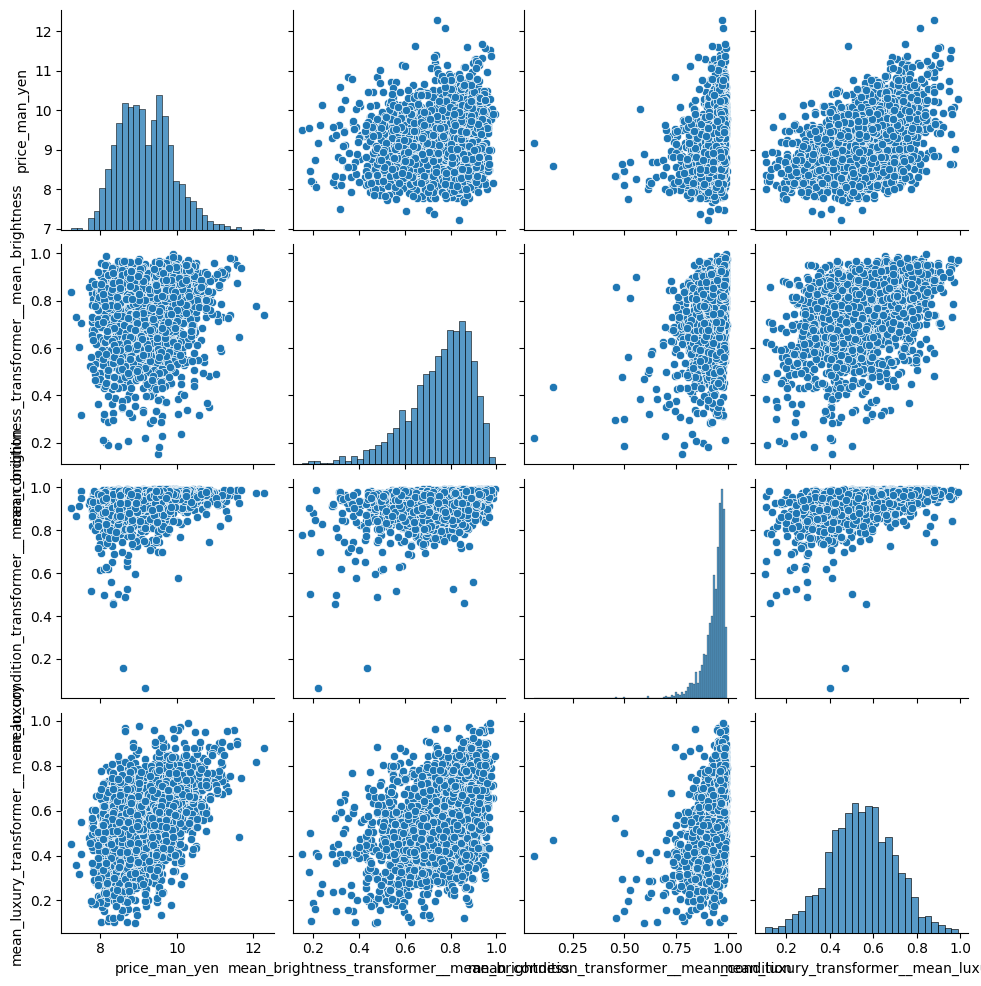

In [42]:
plot2 = sns.pairplot(train_data[['price_man_yen','mean_brightness_transformer__mean_brightness','mean_condition_transformer__mean_condition', 'mean_luxury_transformer__mean_luxury']])

In [32]:
X_train_preprocessed
is_bad = X_train_preprocessed['num_transformer__floor_number'] > X_train_preprocessed["num_transformer__floors_total"]
X_train_preprocessed[is_bad]

,keep_rooms__rooms_num,num_transformer__area_sqm,num_transformer__year_built,num_transformer__floor_number,num_transformer__floors_total,num_transformer__walk_minutes,station_transformer__nearest_station,ordinal_transformer__base_layout,mean_luxury_transformer__mean_luxury,mean_brightness_transformer__mean_brightness,mean_condition_transformer__mean_condition
0,2.0,-0.220727,-0.703704,0.571429,0.111111,-0.500000,2690.250981,3.0,0.220785,0.447754,0.887777
3,3.0,0.487960,-0.925926,-0.142857,-0.666667,-0.666667,9721.328697,3.0,0.430664,0.655273,0.920247
4,3.0,0.448300,-0.703704,0.285714,-0.111111,1.000000,11840.994629,3.0,0.266992,0.637305,0.867578
6,3.0,0.692871,0.814815,1.000000,0.222222,-0.333333,7803.110313,3.0,0.860677,0.950846,0.991536
7,2.0,-1.205146,-0.962963,-0.428571,-0.444444,-0.166667,6452.177383,1.0,0.453993,0.793837,0.979601
...,...,...,...,...,...,...,...,...,...,...,...
2301,1.0,-1.002125,-0.851852,-0.285714,-0.444444,0.000000,26877.078300,3.0,0.422995,0.743646,0.928229
2304,1.0,-1.495515,-1.111111,-0.142857,-0.222222,-0.500000,7073.758673,3.0,0.774089,0.869466,0.962240
2307,1.0,-1.648489,-0.629630,-0.142857,-0.222222,1.166667,7034.201278,2.0,0.472656,0.710156,0.941250
2308,3.0,0.487960,-0.925926,-0.142857,-0.666667,0.500000,9721.328697,3.0,0.635347,0.923816,0.966704


In [33]:
listing_with_scores = pd.read_csv('data_dump/listings_with_scores.csv')
listing_with_scores

def fix_floating(row):
    if row['floor_number'] > row['floors_total']:
        row['floors_total'] = row['floor_number'] * 2

    return row

listing_with_scores = listing_with_scores.apply(fix_floating, axis=1)
listing_with_scores

,level_0,source_id,url,price_man_yen,area_sqm,year_built,floor_number,floors_total,address,nearest_station,...,brightness_bathroom,brightness_bedroom,brightness_kitchen,brightness_living_room,brightness_toilet,condition_bathroom,condition_bedroom,condition_kitchen,condition_living_room,condition_toilet
0,1,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,...,0.858398,0.320312,0.873047,NaN,0.878906,0.927734,0.707031,0.970703,NaN,0.851562
1,2,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,...,0.650391,0.685547,0.655273,NaN,0.925781,0.970703,0.971680,0.872070,NaN,0.652344
2,3,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,...,0.226562,0.724609,0.851562,NaN,0.906250,0.863281,0.902344,0.980469,NaN,0.914062
3,4,78385243,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_7...,1700.0,40.10,1985,1.0,5.0,東京都足立区青井１-16-9 [ ■ 周辺環境 ],青井駅,...,0.411458,0.798828,NaN,NaN,NaN,0.868490,0.955078,NaN,NaN,NaN
4,5,78151350,https://suumo.jp/ms/chuko/tokyo/sc_bunkyo/nc_7...,1800.0,26.29,1977,5.0,5.0,東京都文京区小石川５ [ ■ 周辺環境 ],茗荷谷駅,...,0.320312,0.226562,0.396484,NaN,NaN,0.919922,0.941406,0.990234,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3298,3868,78637031,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,118000.0,106.76,2024,5.0,10.0,東京都渋谷区神宮前６ [ ■ 周辺環境 ],明治神宮前駅,...,0.880208,0.924479,0.956055,0.994141,NaN,0.973958,0.985677,0.985352,0.998047,NaN
3299,3869,78783232,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,79800.0,152.01,2014,2.0,4.0,東京都渋谷区広尾３-12-17 [ ■ 周辺環境 ],広尾駅,...,NaN,NaN,0.980469,0.975000,NaN,NaN,NaN,0.972656,0.952344,NaN
3300,3870,78931650,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,137000.0,214.98,2024,4.0,8.0,東京都渋谷区鉢山町 [ ■ 周辺環境 ],代官山駅,...,0.802734,0.320312,0.972656,0.929688,0.730469,0.996094,0.988281,1.000000,0.994141,0.968750
3301,3871,79115894,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,79800.0,177.80,2025,2.0,4.0,東京都渋谷区西原３ [ ■ 周辺環境 ],代々木上原駅,...,0.963542,0.904948,0.990234,0.980469,NaN,0.937500,0.993490,0.986328,1.000000,NaN


In [34]:
is_bad2 = listing_with_scores['floor_number'] > listing_with_scores['floors_total']
listing_with_scores[is_bad2]

,level_0,source_id,url,price_man_yen,area_sqm,year_built,floor_number,floors_total,address,nearest_station,...,brightness_bathroom,brightness_bedroom,brightness_kitchen,brightness_living_room,brightness_toilet,condition_bathroom,condition_bedroom,condition_kitchen,condition_living_room,condition_toilet


## delete folders from suumo_images that are no longer needed


In [35]:
# ids_to_delete = listing_data[listing_data['image_count'] < 5]['source_id']
# len(ids_to_delete)

In [36]:
# def delete_folder_by_name(source_id):
#     """
#     Deletes a folder and all its contents recursively.

#     Args:
#         folder_path (str or path-like object): The path to the folder to be deleted.
#     """
#     source_id = 0000
#     folder_path = f'raw_data/suumo_images/{source_id}'
#     if os.path.isdir(folder_path):
#         try:
#             # Recursively remove the directory and all its contents
#             shutil.rmtree(folder_path)
#             print(f"Directory '{folder_path}' has been removed successfully.")
#         except OSError as e:
#             print(f"Error: {folder_path} : {e.strerror}")
#     else:
#         print(f"Error: Directory '{folder_path}' not found or is not a directory.")